In [27]:
import os
import cv2
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.applications import VGG16
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, cohen_kappa_score

In [2]:
# Set seeds to make the experiment more reproducible.
from tensorflow.random import set_seed 
def seed_everything(seed=0):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    set_seed(0)
seed_everything()

## Check GPU resource

In [3]:
!nvidia-smi -L

'nvidia-smi' is not recognized as an internal or external command,
operable program or batch file.


## Load data

In [4]:
train = pd.read_csv(r"C:\Users\ACER\OneDrive\Desktop\project\IDRiD_Dataset\B. Disease Grading\2. Groundtruths\a. IDRiD_Disease Grading_Training Labels.csv")
test  = pd.read_csv(r"C:\Users\ACER\OneDrive\Desktop\project\IDRiD_Dataset\B. Disease Grading\2. Groundtruths\b. IDRiD_Disease Grading_Testing Labels.csv")

## EDA

In [5]:
print('Number of train samples: ', train.shape[0])
print('Number of test samples: ', test.shape[0])

Number of train samples:  413
Number of test samples:  103


C:\Users\ACER\AppData\Local\Temp\ipykernel_24732\157022920.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Retinopathy grade", data=train, palette="GnBu_d")


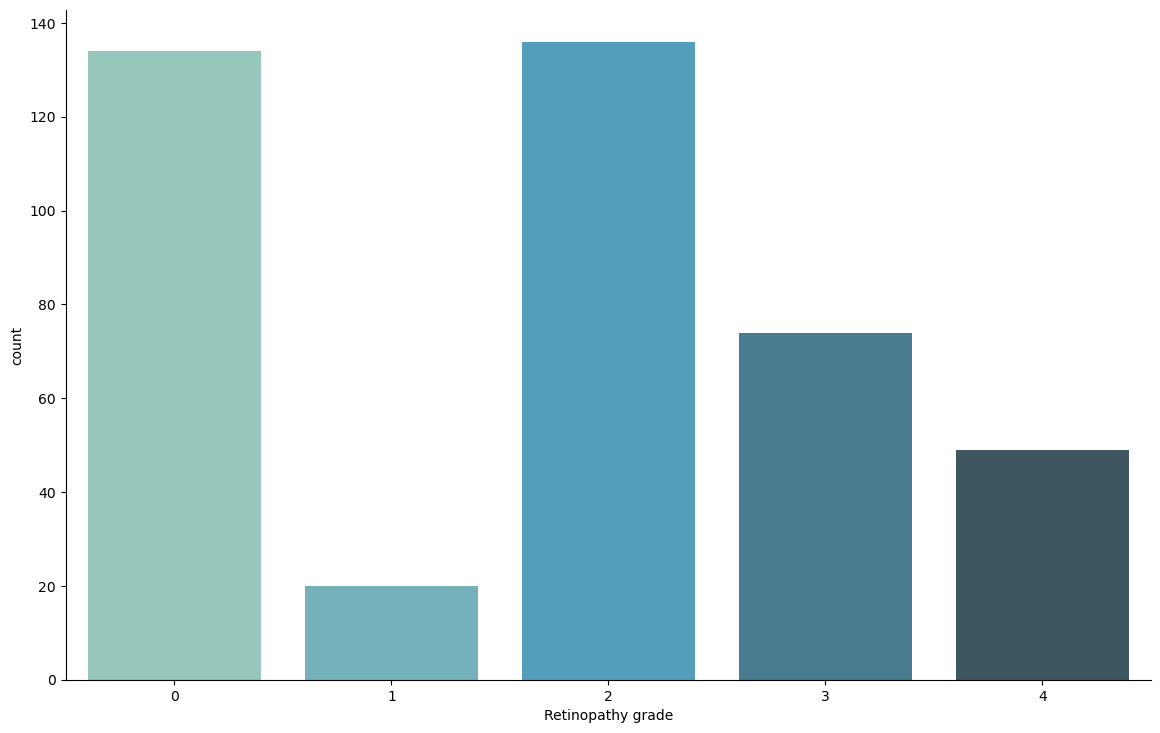

In [7]:
f, ax = plt.subplots(figsize=(14, 8.7))
ax = sns.countplot(x="Retinopathy grade", data=train, palette="GnBu_d")
sns.despine()
plt.show()



# 0 = No DR (eye sahi hai)
# 1 = Mild
# 2 = Moderate
# 3 = Severe
# 4 = Proliferative DR (sabse kharab)

## Check images

## See some of the images

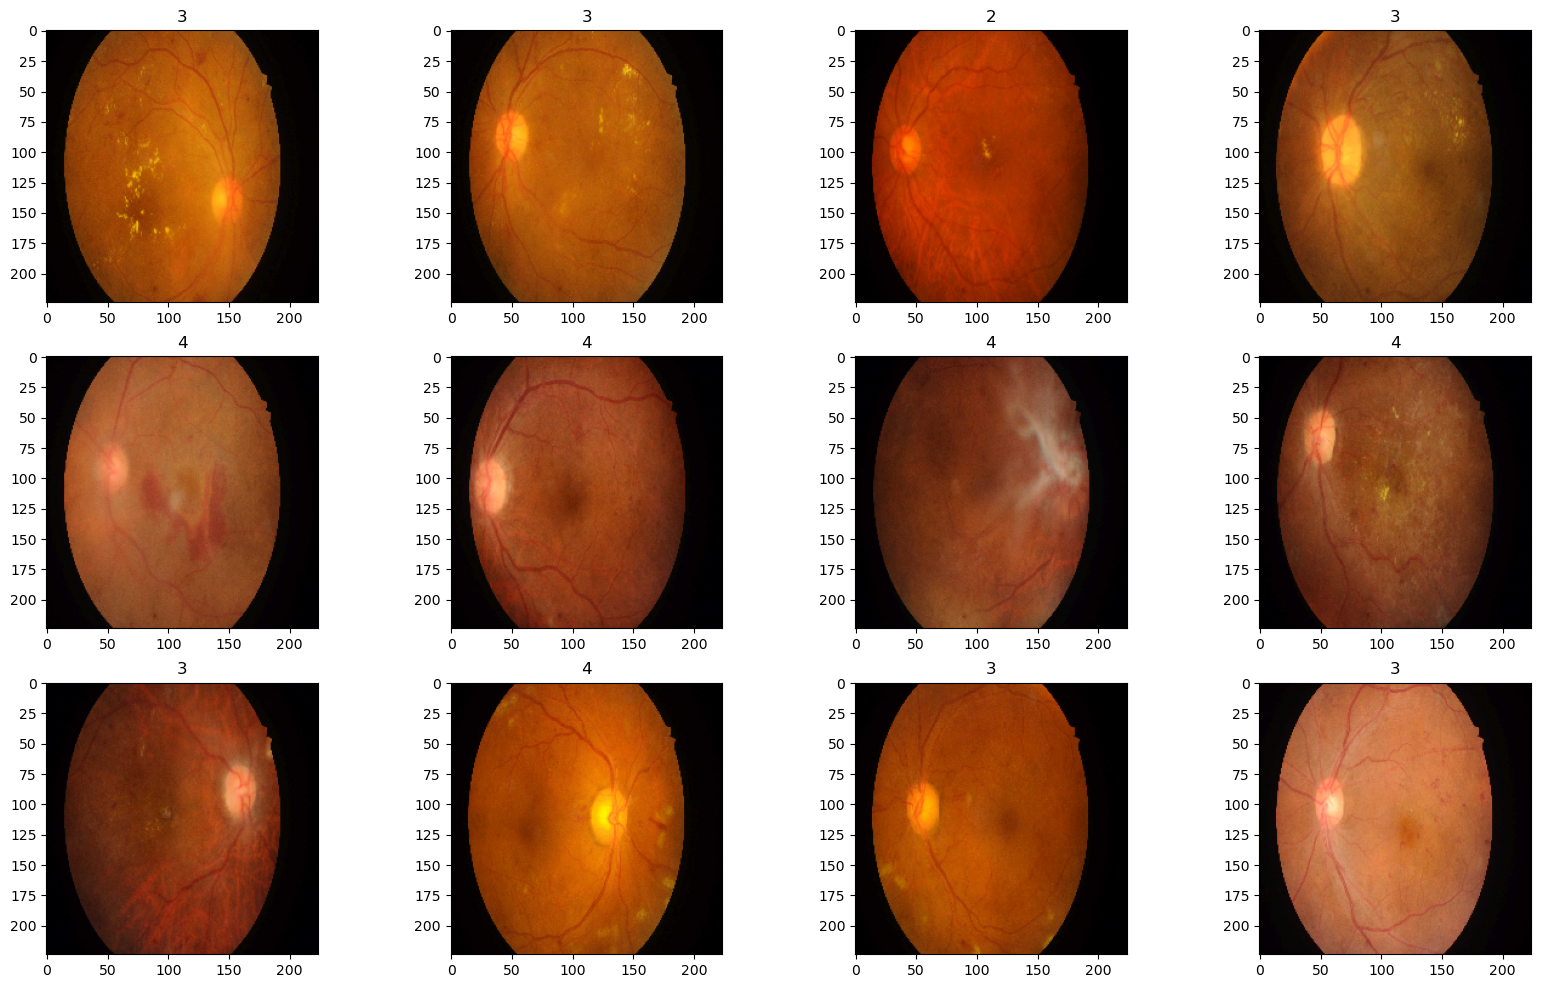

In [9]:
trainpath = r"C:\Users\ACER\OneDrive\Desktop\project\IDRiD_Dataset\B. Disease Grading\1. Original Images\a. Training Set" + "\\"
testpath  = r"C:\Users\ACER\OneDrive\Desktop\project\IDRiD_Dataset\B. Disease Grading\1. Original Images\b. Testing Set" + "\\"

def display_samples(df, columns=4, rows=3):
    fig=plt.figure(figsize=(5*columns, 4*rows))

    for i in range(columns*rows):
        image_path = df.loc[i,'Image name']
        image_id = df.loc[i,'Retinopathy grade']
        img = cv2.imread(trainpath+f'{image_path}'+ '.jpg')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224,224))
        
        fig.add_subplot(rows, columns, i+1)
        plt.title(image_id)
        plt.imshow(img)
    
    # plt.tight_layout()

display_samples(train)



# working.
# Ye cell train data se 12 images dikha raha hai (4 columns × 3 rows).
# Har image ke upar uska grade likha hai.
# Bas check karne ke liye ki images sahi load ho rahi hain aur grade sahi dikh raha hai.

## Preprocecss data

In [10]:
train["Image name"] = train["Image name"].apply(lambda x: x + ".jpg")
test["Image name"] = test["Image name"].apply(lambda x: x + ".jpg")
train['Retinopathy grade'] = train['Retinopathy grade'].astype('str')


# # working
# Image name mein .jpg add kar raha hai (kyunki files IDRiD_001.jpg naam se hain)
# Grade ko string bana raha hai (kyunki generator categorical mode mein string maangta hai)

In [11]:
test['Retinopathy grade'] = test['Retinopathy grade'].astype('str')
train.head()



# #working
# Test ke grade ko bhi string bana raha hai
# train.head() se pehli 5 rows dikha raha hai

,Image name,Retinopathy grade,Risk of macular edema,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,IDRiD_001.jpg,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IDRiD_002.jpg,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IDRiD_003.jpg,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IDRiD_004.jpg,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IDRiD_005.jpg,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
train['Retinopathy grade'].value_counts()



# working
# Ye cell train data mein har grade ki count dikhayega. Output batao.


# Grade 2 → 136 images
# Grade 0 → 134 images
# Grade 3 → 74 images
# Grade 4 → 49 images
# Grade 1 → 20 images

Retinopathy grade
2    136
0    134
3     74
4     49
1     20
Name: count, dtype: int64

## Train Test Split

In [13]:
train, valid = train_test_split(train, test_size=0.1, shuffle=True, random_state=0, stratify=train['Retinopathy grade']) 
train['Retinopathy grade'].value_counts()


# working
# 90% → train (model sikhne ke liye)
# 10% → valid (training ke time check karne ke liye)
# stratify ka matlab: har class ka proportion same rahe dono mein.

Retinopathy grade
2    122
0    120
3     67
4     44
1     18
Name: count, dtype: int64

## Balance Training Data

In [14]:
def oversample(df):
    classes = df['Retinopathy grade'].value_counts().to_dict()
    most = max(classes.values())
    classes_list = []
    for key in classes:
        classes_list.append(df[df['Retinopathy grade'] == key]) 
    classes_sample = []
    for i in range(1,len(classes_list)):
        classes_sample.append(classes_list[i].sample(most, replace=True, random_state=0))
    df_maybe = pd.concat(classes_sample)
    final_df = pd.concat([df_maybe,classes_list[0]], axis=0)
    final_df = final_df.reset_index(drop=True)
    return final_df

def undersample(df):
    classes = df['Retinopathy grade'].value_counts().to_dict()
    least_class_amount = min(classes.values())
    classes_list = []
    for key in classes:
        classes_list.append(df[df['Retinopathy grade'] == key]) 
    classes_sample = []
    for i in range(0,len(classes_list)-1):
        classes_sample.append(classes_list[i].sample(least_class_amount))
    df_maybe = pd.concat(classes_sample)
    final_df = pd.concat([df_maybe,classes_list[-1]], axis=0)
    final_df = final_df.reset_index(drop=True)
    return final_df


# # working
# Ye cell sirf 2 functions define kar raha hai (abhi chala nahi raha):
# oversample → minority classes ko duplicate karke badhata hai (sabse badi class ke barabar)
# undersample → majority classes ko kam karta hai (sabse chhoti class ke barabar)

In [15]:
train = oversample(train)
train = undersample(train)
train['Retinopathy grade'].value_counts()

Retinopathy grade
0    122
3    122
4    122
1    122
2    122
Name: count, dtype: int64

In [16]:
sample_amounts = {'0': 50, '1': 50, '2': 50, '3': 50, '4': 50}
train = (
            train.groupby('Retinopathy grade').apply(lambda g: g.sample(
            # lookup number of samples to take
            n = sample_amounts[g.name],
            # enable replacement if len is less than number of samples expected
            replace=len(g) < sample_amounts[g.name]  
    ))
)
train['Retinopathy grade'].value_counts()

C:\Users\ACER\AppData\Local\Temp\ipykernel_24732\3910731002.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train.groupby('Retinopathy grade').apply(lambda g: g.sample(


Retinopathy grade
0    50
1    50
2    50
3    50
4    50
Name: count, dtype: int64

## Visualize all Train Valid Test

In [18]:
#Visualize final Train Valid Test
print('All length: ', len(train)+len(valid)+len(test))
print()
print('Train length : ',len(train))
print(train['Retinopathy grade'].value_counts())
print()
print('Valid length : ',len(valid))
print(valid['Retinopathy grade'].value_counts())
print()
print(test['Retinopathy grade'].value_counts())



# #working 
# Ye cell final counts dikha raha hai — train, valid, test teeno ka.

All length:  395

Train length :  250
Retinopathy grade
0    50
1    50
2    50
3    50
4    50
Name: count, dtype: int64

Valid length :  42
Retinopathy grade
0    14
2    14
3     7
4     5
1     2
Name: count, dtype: int64

Retinopathy grade
0    34
2    32
3    19
4    13
1     5
Name: count, dtype: int64


In [19]:
WIDE = 224


# # working
# Ye bas WIDE = 224 set kar raha hai — matlab images 224×224 size ki hongi (VGG16 ke liye)

In [20]:
def preprorgb(img):
    img = cv2.addWeighted(img,5, cv2.GaussianBlur(img , (0,0) , WIDE/40) ,-5 ,100)
    return img

# working 
# Ye ek sharpening function hai (image ko thoda clear karta hai). Bas define hua hai, use nahi hua — notebook mein comment out hai.

## Data generator

In [21]:
train_datagen=ImageDataGenerator(#preprocessing_function  = preprorgb,
                                 rescale                 = 1./255,
                                 rotation_range          = 5,
                                 width_shift_range       = 0.05,
                                 height_shift_range      = 0.05,)
                                 #vertical_flip           = True)

train_datagen_sample=ImageDataGenerator(#preprocessing_function  = preprorgb,
                                        rotation_range          = 5,
                                        width_shift_range       = 0.05,
                                        height_shift_range      = 0.05,)
                                        #vertical_flip           = True)

train_generator=train_datagen.flow_from_dataframe(
    dataframe=train,
    directory=trainpath,
    x_col="Image name",
    y_col="Retinopathy grade",
    batch_size=10,
    class_mode="categorical",
    target_size=(WIDE,WIDE),
    shuffle=True)

train_generator_sample=train_datagen_sample.flow_from_dataframe(
    dataframe=train,
    directory=trainpath,
    x_col="Image name",
    y_col="Retinopathy grade",
    batch_size=10,
    class_mode="categorical",
    target_size=(WIDE,WIDE),
    shuffle=True)   

valid_test_datagen=ImageDataGenerator(#preprocessing_function  = preprorgb,
                                      rescale=1./255)

valid_generator=valid_test_datagen.flow_from_dataframe(
    dataframe=valid,
    directory=trainpath,
    x_col="Image name",
    y_col="Retinopathy grade",
    batch_size=1,
    class_mode="categorical",    
    target_size=(WIDE,WIDE),
    shuffle=False)



# # working
# Ye 3 generators banata hai:
# 1. train_generator → training images (rescale + thoda rotate/shift)
# 2. train_generator_sample → sirf dikhane ke liye (bina rescale)
# 3. valid_generator → validation images (sirf rescale)

Found 250 validated image filenames belonging to 5 classes.
Found 250 validated image filenames belonging to 5 classes.
Found 42 validated image filenames belonging to 5 classes.


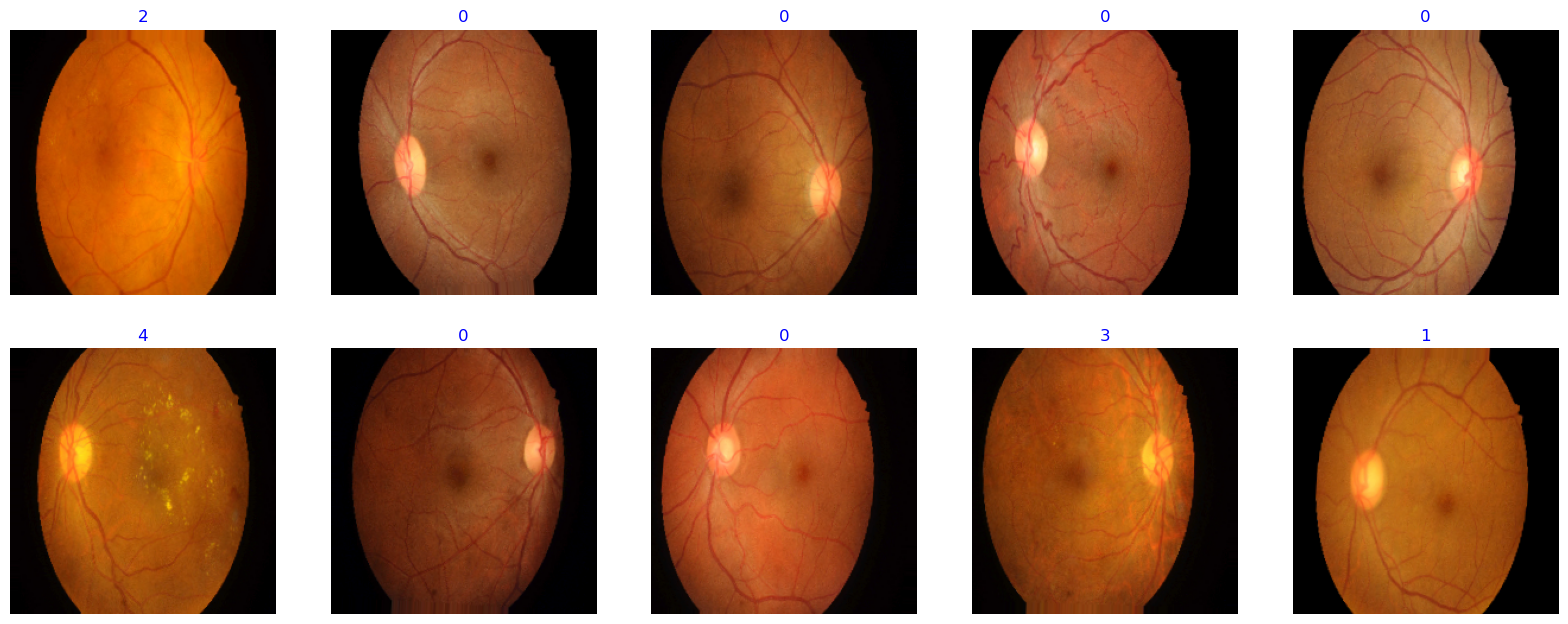

In [22]:
def show_image_samples(gen):
    t_dict=gen.class_indices
    classes=list(t_dict.keys())    
    images,labels=next(gen) # get a sample batch from the generator 
    plt.figure(figsize=(20, 20))
    length=len(labels)
    if length<25:   #show maximum of 25 images
        r=length
    else:
        r=25    
    for i in range(r):        
        plt.subplot(5, 5, i + 1)
        image=images[i]/255
        plt.imshow(image,cmap='gray')
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color='blue', fontsize=12)
        plt.axis('off')
    plt.show()
show_image_samples(train_generator_sample)


# # working
# Ye function generator se ek batch images leta hai (max 25) aur unhe grade label ke saath dikhata hai.
# Augmentation (rotate/shift) ke baad images kaisi dikh rahi hain, ye check karne ke liye.

## VGG16 50 baseline modelbase_model = VGG16(weights="imagenet", include_top=False,  input_shape=(WIDE,WIDE,3))

In [23]:
base_model = VGG16(weights="imagenet", include_top=False,  input_shape=(WIDE,WIDE,3))

# # working
# VGG16 model load kar raha hai — ImageNet pe pretrained, bina top layer ke.
# Ye base model hoga (isse hum apna custom head lagayenge).

In [24]:
base_model.trainable = False

# add custom top layers
last_output = base_model.output
print(last_output.shape)

# # working
# base_model ke saare layers freeze kar raha hai (train nahi honge).
# last_output = VGG16 ka final output layer.
# print uski shape — kya shape hai wo batao.

(None, 7, 7, 512)


In [25]:
# Flatten the output layer to 1 dimension
x = layers.Flatten()(last_output)
# Add a fully connected layer with 1,024 hidden units and ReLU activation
x = layers.Dense(1024, activation='relu')(x)
# Add a dropout rate of 0.2
x = layers.Dropout(0.2)(x)
x = layers.Dense(512, activation='relu')(x)
# Add a dropout rate of 0.2
x = layers.Dropout(0.2)(x)
# Add a final sigmoid layer for classification
x = layers.Dense(5, activation='softmax')(x)

# Configure and compile the model
model = Model(base_model.input, x)
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.summary()



# # working
# VGG16 ke upar custom layers lagata hai:
# Flatten → Dense(1024) → Dropout → Dense(512) → Dropout → Dense(5, softmax)
# 5 kyunki 5 grades hain (0,1,2,3,4).
# model.compile se training ke liye ready karta hai (adam + categorical_crossentropy).

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    25,691,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         2,56

 Total params: 40,933,189 (156.15 MB)

 Trainable params: 26,218,501 (100.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [26]:
STEP_SIZE_TRAIN = train_generator.n//train_generator.batch_size
STEP_SIZE_VALID = valid_generator.n//valid_generator.batch_size


# # working
# Har epoch mein kitne batches chalenge wo calculate kar raha hai.
# Train ke liye aur valid ke liye alag-alag.

In [ ]:
%%time
history = model.fit(
    train_generator,
    steps_per_epoch=STEP_SIZE_TRAIN,
    epochs=50,
    validation_data=valid_generator,
    validation_steps=STEP_SIZE_VALID
)

# model training.

Epoch 1/50
13/25 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.1615 - loss: 9.2161

In [ ]:
model.evaluate(valid_generator)

# working
#Validation accuracy = 38%, loss = 1.45.
#Ye kam hai, lekin expected hai — sirf 250 images, 50 epochs, aur frozen VGG16 se zyada nahi milta.

42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - accuracy: 0.3810 - loss: 1.4514


[1.4513680934906006, 0.380952388048172]

Text(0.5, 1.0, 'Training and validation loss')

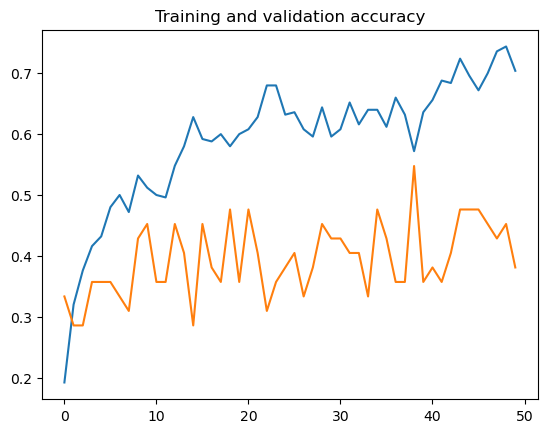

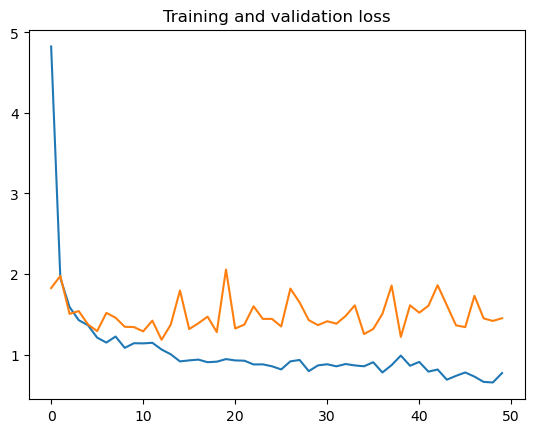

In [ ]:
import matplotlib.pyplot as plt
# Retrieve a list of accuracy results on training and validation data
# sets for each training epoch
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Retrieve a list of list results on training and validation data
# sets for each training epoch
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get number of epochs
epochs = range(len(acc))

# Plot training and validation accuracy per epoch
plt.plot(epochs, acc)
plt.plot(epochs, val_acc)
plt.title('Training and validation accuracy')

plt.figure()

# Plot training and validation loss per epoch
plt.plot(epochs, loss)
plt.plot(epochs, val_loss)
plt.title('Training and validation loss')



# # working
# Chalao — 2 graphs aayenge:
# Training vs Validation accuracy
# Training vs Validation loss

## Predict

In [ ]:
# complete_datagen = ImageDataGenerator(#preprocessing_function  = preprorgb,
#                                       rescale=1./255)

# complete_generator = complete_datagen.flow_from_dataframe(  
#         dataframe=test,
#         directory = testpath,
#         x_col="Image name",
#         target_size=(WIDE,WIDE),
#         batch_size=1,
#         shuffle=False,
#         class_mode=None)

# STEP_SIZE_COMPLETE = complete_generator.n//complete_generator.batch_size
# test_preds = model.predict_generator(complete_generator, verbose=1, steps=STEP_SIZE_COMPLETE)
# test_preds = [np.argmax(pred) for pred in test_preds]

Found 103 validated image filenames.


AttributeError: 'Functional' object has no attribute 'predict_generator'

In [ ]:
complete_datagen = ImageDataGenerator(rescale=1./255)

complete_generator = complete_datagen.flow_from_dataframe(
        dataframe=test,
        directory=testpath,
        x_col="Image name",
        target_size=(WIDE,WIDE),
        batch_size=1,
        shuffle=False,
        class_mode=None)

STEP_SIZE_COMPLETE = complete_generator.n//complete_generator.batch_size
test_preds = model.predict(complete_generator, verbose=1, steps=STEP_SIZE_COMPLETE)
test_preds = [np.argmax(pred) for pred in test_preds]



# # working
# Test set pe model se prediction kar raha hai.
# 103 images ka predicted grade nikalta hai (0-4).
# test_preds mein saare predictions save ho jaate hain.

Found 103 validated image filenames.
103/103 ━━━━━━━━━━━━━━━━━━━━ 16s 152ms/step


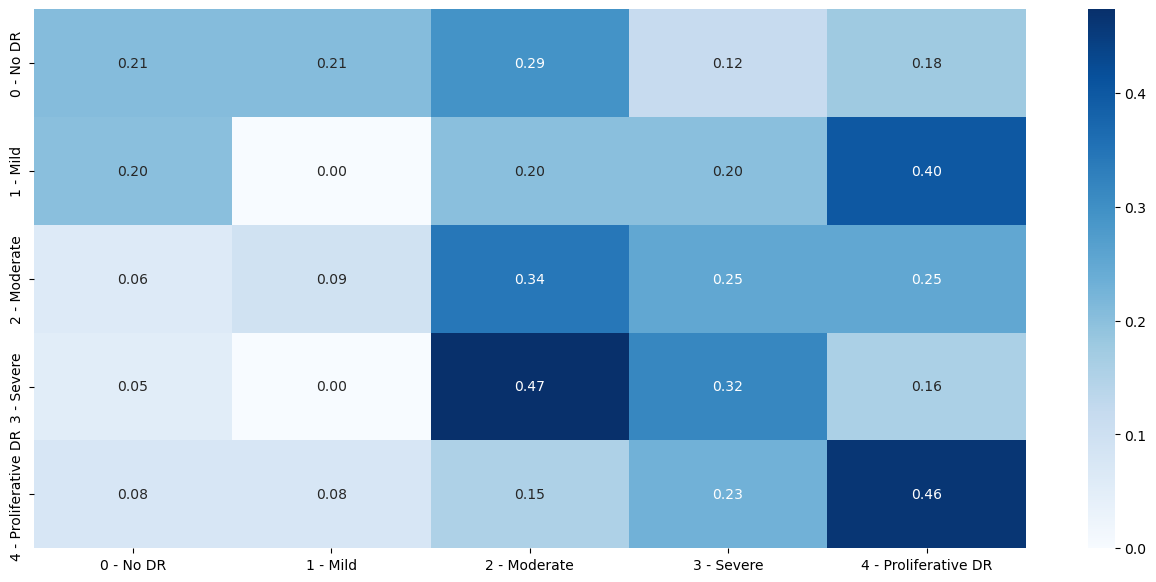

In [ ]:
labels = ['0 - No DR', '1 - Mild', '2 - Moderate', '3 - Severe', '4 - Proliferative DR']
cnf_matrix = confusion_matrix(test['Retinopathy grade'].astype('int'), test_preds)
cnf_matrix_norm = cnf_matrix.astype('float') / cnf_matrix.sum(axis=1)[:, np.newaxis]
df_cm = pd.DataFrame(cnf_matrix_norm, index=labels, columns=labels)
plt.figure(figsize=(16, 7))
plt.xlabel("Predicted")
plt.ylabel("Actual")
sns.heatmap(df_cm, annot=True, fmt='.2f', cmap="Blues")
plt.show()



# # working
# Confusion matrix banata hai (normalized) — heatmap ke roop mein.
# Har row = actual grade, har column = predicted grade.
# Diagonal pe jo value zyada, matlab wahan sahi prediction hui.
# Off-diagonal values = galtiyan (kitni baar galat predict kiya).

# Grade 3 (Severe) → 0.47 (47% sahi)
# Grade 2 (Moderate) → 0.47 (47% sahi)

## Quadratic Weighted Kappa

In [ ]:
print("Test Cohen Kappa score: %.3f" % cohen_kappa_score(test_preds, test['Retinopathy grade'].astype('int'), weights='quadratic'))

# # working
# QWK (Quadratic Weighted Kappa) score nikalta hai.
# Ye DR grading ka main metric hai — 0 se 1 tak.
# Zyada = better. 0 = random, 1 = perfect.
# Ye accuracy se better hai kyunki ordinal data ke liye sahi penalty deta hai.

# QWK = 0.247 — kam hai. Baseline model ke liye expected.

Test Cohen Kappa score: 0.247


## Metric report

In [ ]:
# import classification_report
from sklearn.metrics import classification_report

# # working
# sklearn se classification_report import karta hai.
# Ye precision, recall, f1-score har class ke liye calculate karega.

In [ ]:
# get the classification report
print(classification_report(test['Retinopathy grade'].astype('int'), test_preds))


# # working
# Har grade ke liye precision, recall, f1-score dikhata hai.
# Precision = jitna predict kiya usme kitna sahi tha.
# Recall = actual jitne the unme se kitne pakde.
# f1-score = precision aur recall ka balance.
# support = us class ki kitni images thi.




# Grade	Precision	Recall	F1
# 0 (No DR)	0.58	0.21	0.30
# 1 (Mild)	0.00	0.00	0.00
# 2 (Moderate)	0.33	0.34	0.34
# 3 (Severe)	0.27	0.32	0.29
# 4 (Prolif)	0.24	0.46	0.32
# Overall accuracy = 29%, QWK = 0.247.

              precision    recall  f1-score   support

           0       0.58      0.21      0.30        34
           1       0.00      0.00      0.00         5
           2       0.33      0.34      0.34        32
           3       0.27      0.32      0.29        19
           4       0.24      0.46      0.32        13

    accuracy                           0.29       103
   macro avg       0.29      0.27      0.25       103
weighted avg       0.38      0.29      0.30       103



In [1]:
print("project ml part is done now you can show with using streamlit")

project ml part is done now you can show with using streamlit
